<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/Lab3/lab3_classification_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# =========================
# 1) Install & Import
# =========================
!pip install geopandas rasterio scikit-learn -q

In [35]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [2]:
# =========================
# 2) Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# =========================
# 3) Load CSV (2 datasets)
# =========================
csv1_path = '/content/drive/MyDrive/GEE_Export/S2_Training_4Class.csv'
csv2_path = '/content/drive/MyDrive/GEE_Export/S2_Training_4Class300.csv'

df1 = pd.read_csv(csv1_path)
df2 = pd.read_csv(csv2_path)

print("CSV1:", df1.shape)
print("CSV2:", df2.shape)

CSV1: (600, 13)
CSV2: (1200, 13)


In [23]:
# =========================
# 4) Prepare Features
# =========================
features = [
    'B2', 'B3', 'B4', 'B8', 'B11', 'B12',
    'NDVI', 'NDWI', 'NDBI', 'NDMI'
]

X1 = df1[features].values.astype('float32')
y1 = df1['class'].values

X2 = df2[features].values.astype('float32')
y2 = df2['class'].values


In [24]:
# =========================
# 5) Combine Dataset
# =========================
X_combined = np.vstack([X1, X2])
y_combined = np.hstack([y1, y2])

print("Original:", X1.shape)
print("Combined:", X_combined.shape)

Original: (600, 10)
Combined: (1800, 10)


In [25]:
# =========================
# 6) Class Distribution
# =========================
def show_dist(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c}")

show_dist(y1, "CSV1")
show_dist(y_combined, "Combined")


CSV1 distribution:
Class 0: 150
Class 1: 150
Class 2: 150
Class 3: 150

Combined distribution:
Class 0: 450
Class 1: 450
Class 2: 450
Class 3: 450


In [26]:
# =========================
# 7) Train Function
# =========================
def train_rf(X, y, title=""):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    print(f"\n=== {title} ===")
    print("Accuracy:", acc)
    print("Kappa:", kappa)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return rf, acc


In [27]:
# =========================
# 8) Train Compare
# =========================
rf_1, acc_1 = train_rf(X1, y1, "CSV1 Only")
rf_2, acc_2 = train_rf(X_combined, y_combined, "CSV1 + CSV2")

print("\n🔥 Accuracy Improvement:", acc_2 - acc_1)



=== CSV1 Only ===
Accuracy: 1.0
Kappa: 1.0

Confusion Matrix:
 [[33  0  0  0]
 [ 0 29  0  0]
 [ 0  0 28  0]
 [ 0  0  0 30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


=== CSV1 + CSV2 ===
Accuracy: 1.0
Kappa: 1.0

Confusion Matrix:
 [[ 79   0   0   0]
 [  0  79   0   0]
 [  0   0 107   0]
 [  0   0   0  95]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        79
           1       1.00      1.00      1.00        79
           2       1.00      1.00      1.00       107
           3       1.00      1

In [28]:
# =========================
# 9) Select Best Model
# =========================
rf_final = rf_2 if acc_2 > acc_1 else rf_1
print("\nUsing model:", "Combined" if acc_2 > acc_1 else "CSV1")


Using model: CSV1


In [30]:
# =========================
# 10) Load Raster
# =========================
tif_path = '/content/drive/MyDrive/GE338/LAB3/S2/S2Lab3allbands-0000000000-0000000000.tif'

with rasterio.open(tif_path) as src:
    B2 = src.read(2).astype('float32')
    B3 = src.read(3).astype('float32')
    B4 = src.read(4).astype('float32')
    B8 = src.read(8).astype('float32')
    B11 = src.read(11).astype('float32')
    B12 = src.read(12).astype('float32')


In [31]:
# =========================
# 11) Indices
# =========================
ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
ndbi = (B11 - B8) / (B11 + B8 + 1e-6)
ndmi = (B8 - B11) / (B8 + B11 + 1e-6)

In [32]:
# =========================
# 12) Stack
# =========================
stack = np.stack([
    B2, B3, B4, B8, B11, B12,
    ndvi, ndwi, ndbi, ndmi
], axis=-1)


In [33]:
# =========================
# 13) Predict RF Map
# =========================
X_full = stack.reshape(-1, stack.shape[-1])

pred = rf_final.predict(X_full)
pred_map = pred.reshape(stack.shape[:2]).astype('int32')


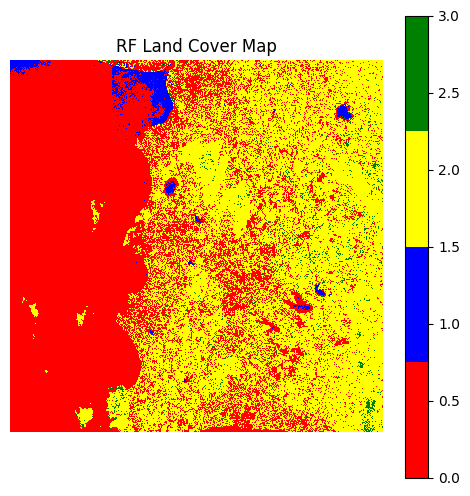

In [37]:
# =========================
# 14) Plot RF Map
# =========================
colors = ['red', 'blue', 'yellow', 'green']
cmap = ListedColormap(colors)

plt.figure(figsize=(6,6))
plt.imshow(
    pred_map[::5, ::5],
    cmap=cmap,
    interpolation='nearest',
    vmin=0,
    vmax=3
)
plt.colorbar()
plt.title("RF Land Cover Map")
plt.axis('off')
plt.show()

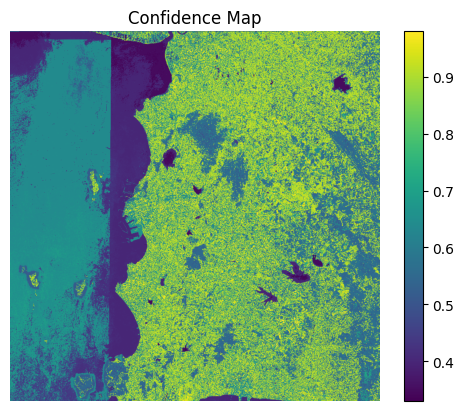

In [38]:
# =========================
# 15) Confidence Map
# =========================
probs = rf_final.predict_proba(X_full)
confidence = np.max(probs, axis=1)

conf_map = confidence.reshape(stack.shape[:2])

plt.imshow(conf_map[::5, ::5], cmap='viridis')
plt.colorbar()
plt.title("Confidence Map")
plt.axis('off')
plt.show()

In [41]:
# =========================
# 16) KMeans (Fix NaN)
# =========================
from sklearn.cluster import KMeans

# reshape raster เป็น 2D
X_full = stack.reshape(-1, stack.shape[-1])

# 🔥 สร้าง mask กรอง NaN
mask_valid = ~np.isnan(X_full).any(axis=1)

X_clean = X_full[mask_valid]

print("Original pixels:", X_full.shape)
print("Valid pixels:", X_clean.shape)

# =========================
# Sampling ลด RAM
# =========================
sample_k = min(100000, len(X_clean))
idx_k = np.random.choice(len(X_clean), sample_k, replace=False)

# =========================
# Train KMeans
# =========================
kmeans = KMeans(
    n_clusters=4,      # 4 classes
    random_state=42,
    n_init=10
)

kmeans.fit(X_clean[idx_k])

# =========================
# Predict ทั้งภาพ
# =========================
kmeans_pred = np.full(len(X_full), -1)  # background = -1

kmeans_pred[mask_valid] = kmeans.predict(X_clean)

# =========================
# Create Map
# =========================
kmeans_map = kmeans_pred.reshape(stack.shape[:2])

# =========================
# 🔥 FIX: แปลงเป็น float ก่อนใส่ NaN
# =========================
kmeans_map = kmeans_map.astype('float32')

# remove background
kmeans_map[kmeans_map == -1] = np.nan


Original pixels: (21233664, 10)
Valid pixels: (21224731, 10)


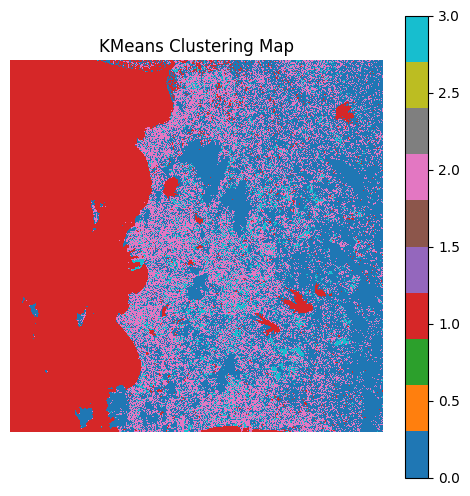

In [42]:
# =========================
# 17) Plot KMeans Map (Correct)
# =========================
plt.figure(figsize=(6,6))

plt.imshow(
    kmeans_map[::5, ::5],
    cmap='tab10',
    interpolation='nearest',
    vmin=0,
    vmax=3
)

plt.colorbar()
plt.title("KMeans Clustering Map")
plt.axis('off')
plt.show()

In [43]:
# =========================
# 18) Debug Check
# =========================
print("Unique values (KMeans):", np.unique(kmeans_map))

Unique values (KMeans): [ 0.  1.  2.  3. nan]


In [44]:
rf_1  # ใช้ CSV1
rf_2  # ใช้ CSV1+CSV2

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [45]:
# =========================
# Predict Map (Both Models)
# =========================
X_full = stack.reshape(-1, stack.shape[-1])

pred1 = rf_1.predict(X_full)
pred2 = rf_2.predict(X_full)

map1 = pred1.reshape(stack.shape[:2]).astype('int32')
map2 = pred2.reshape(stack.shape[:2]).astype('int32')

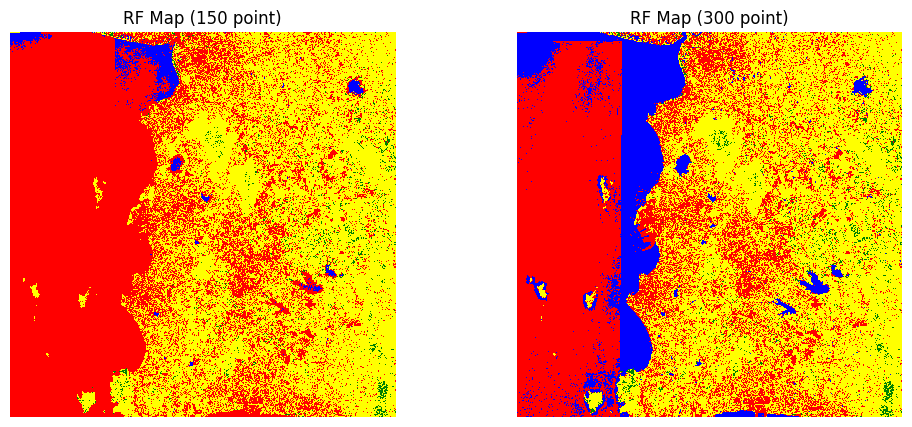

In [51]:
from matplotlib.colors import ListedColormap

colors = ['red', 'blue', 'yellow', 'green']
cmap = ListedColormap(colors)

plt.figure(figsize=(12,5))

# --- CSV1 ---
plt.subplot(1,2,1)
plt.imshow(map1[::5, ::5], cmap=cmap, interpolation='nearest', vmin=0, vmax=3)
plt.title("RF Map (150 point)")
plt.axis('off')

# --- CSV1+CSV2 ---
plt.subplot(1,2,2)
plt.imshow(map2[::5, ::5], cmap=cmap, interpolation='nearest', vmin=0, vmax=3)
plt.title("RF Map (300 point)")
plt.axis('off')

plt.show()

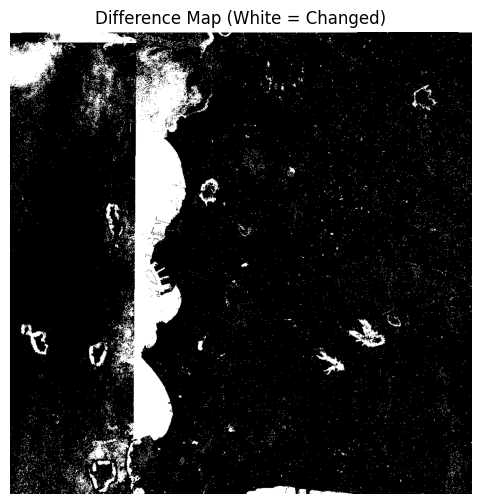

🔄 Percent Changed: 10.534837510850695 %


In [47]:
# =========================
# Difference Map
# =========================
diff_map = map1 != map2   # True = ต่าง

plt.figure(figsize=(6,6))
plt.imshow(diff_map[::5, ::5], cmap='gray')
plt.title("Difference Map (White = Changed)")
plt.axis('off')
plt.show()

# เปอร์เซ็นต์ความต่าง
change_ratio = np.sum(diff_map) / diff_map.size

print("🔄 Percent Changed:", change_ratio * 100, "%")

In [48]:
print("\n=== Accuracy Comparison ===")
print("CSV1:", acc_1)
print("CSV1 + CSV2:", acc_2)
print("Improvement:", acc_2 - acc_1)


=== Accuracy Comparison ===
CSV1: 1.0
CSV1 + CSV2: 1.0
Improvement: 0.0


Shape: (600, 13)

Missing values:
system:index    0
B11             0
B12             0
B2              0
B3              0
B4              0
B8              0
NDBI            0
NDMI            0
NDVI            0
NDWI            0
class           0
.geo            0
dtype: int64

Check Inf:
B2      0
B3      0
B4      0
B8      0
B11     0
B12     0
NDVI    0
NDWI    0
NDBI    0
NDMI    0
dtype: int64

Describe:
               B2          B3          B4          B8         B11         B12  \
count  600.000000  600.000000  600.000000  600.000000  600.000000  600.000000   
mean     0.055977    0.072570    0.070074    0.211968    0.180049    0.122362   
std      0.043922    0.049556    0.068831    0.138878    0.140828    0.119468   
min      0.010850    0.014350    0.005400    0.000000    0.003950    0.002800   
25%      0.029838    0.040975    0.021575    0.026100    0.039700    0.018388   
50%      0.044050    0.058000    0.040825    0.257900    0.157850    0.073075   
75%      0.06351

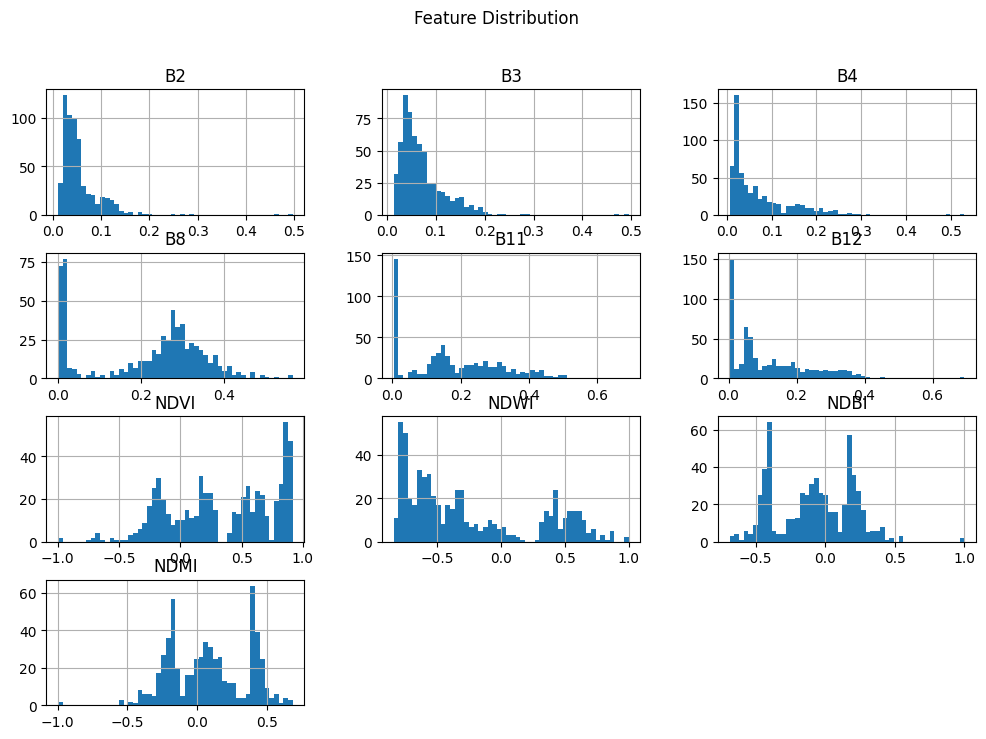

In [49]:
# =========================
# CHECK CSV DATA
# =========================
print("Shape:", df.shape)

# missing values
print("\nMissing values:")
print(df.isna().sum())

# ค่า Inf / -Inf
print("\nCheck Inf:")
print(np.isinf(df[features]).sum())

# สถิติพื้นฐาน
print("\nDescribe:")
print(df[features].describe())

# unique class
print("\nClasses:", np.unique(df['class']))

import matplotlib.pyplot as plt

df[features].hist(figsize=(12,8), bins=50)
plt.suptitle("Feature Distribution")
plt.show()

Class 0: 150
Class 1: 150
Class 2: 150
Class 3: 150


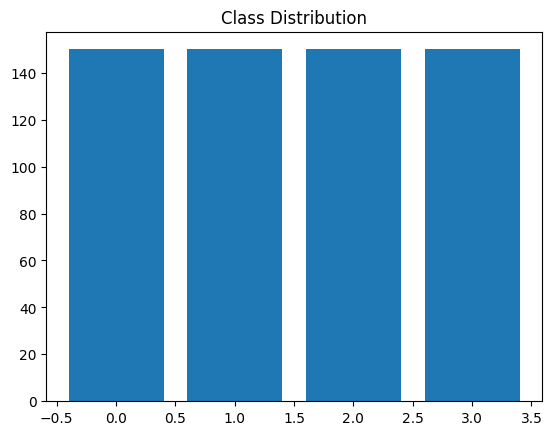

In [50]:
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

plt.bar(unique, counts)
plt.title("Class Distribution")
plt.show()